# Running `mvlse` on your own blackbox

How to take a function you already have and get its level set — the boundary where it
crosses a threshold — out of it.

Five steps:

1. declare the design space, by name, in physical units
2. write the blackbox
3. run the loop
4. read the results
5. look at what the surrogate learned

Then the variants: noisy blackboxes, caching, other kernels, parallel evaluation.

## Setup

From the repository root:

```bash
pip install -e ".[plots]"
```

In [1]:
import numpy as np

from mvlse import (
    Continuous,
    DesignSpace,
    LseConfig,
    Nominal,
    Ordinal,
    run_lse,
)

## 1. Declare the design space

One entry per input variable, keyed by **your own name for it**, in **physical units**.
Pick the class that matches the variable's nature:

| class | use it for | example |
|---|---|---|
| `Continuous(lo, hi)` | a real number on an interval | `Continuous(100.0, 5000.0)` |
| `Ordinal([...])` | discrete levels with a **meaningful order** | `Ordinal(["none", "conv_1_2", "turbo"])` |
| `Nominal([...])` | discrete levels with **no order** | `Nominal(["patch", "dipole", "helix"])` |

The distinction matters: `Ordinal` tells direct-conversion coding that the order is real,
and lets the hypersphere kernels be *checked* against it. Use `Nominal` when there is no
order to claim — imposing a false one is a modelling bias, not a harmless convenience.

At least one `Continuous` variable is required.

In [2]:
space = DesignSpace({
    "range_m":       Continuous(100.0, 5000.0),
    "tx_power_dbm":  Continuous(0.0, 20.0),
    "antenna":       Nominal(["patch", "dipole", "helix"]),
    "coding":        Ordinal(["none", "conv_1_2", "turbo"]),
})

print(space.describe())

DesignSpace: q=2 continuous, r=2 discrete, m=9 categories
  normalize = True  (continuous columns mapped to [0, 1])

  column name             nature     physical                     what the model sees
  ------ ---------------- ---------- ---------------------------- ----------------------------
  0      range_m          continuous [100, 5000]                  [0, 1]
  1      tx_power_dbm     continuous [0, 20]                      [0, 1]
  2      antenna          nominal    patch, dipole, helix         level index 0..2
  3      coding           ordinal    none, conv_1_2, turbo        level index 0..2


`describe()` prints exactly what the model sees. Normalisation is on by default and is
reversible — `encode` / `decode` round-trip, and you can turn it off:

```python
DesignSpace({...}, normalize=False)   # continuous columns stay in physical units
```

Leave it on unless you have a reason; the kernel hyperparameter bounds are calibrated for
inputs on the unit cube.

In [3]:
# encode / decode are public and exact — check it whenever you are unsure what is going on
from mvlse import stratified_doe

w = stratified_doe(space, n_per_category=1, seed=0)
print("encoded row 0 :", w[0])
print("decoded row 0 :", space.decode(w)[:1][0])
print("round-trip max error:", np.abs(space.encode(space.decode(w)) - w).max())

encoded row 0 : [0.63696169 0.26978671 0.         0.        ]
decoded row 0 : Point(range_m=3221.1122678751262, tx_power_dbm=5.395734275277406, antenna='patch', coding='none')
round-trip max error: 1.1102230246251565e-16


## 2. Write the blackbox

A blackbox takes a **batch of points** and returns **one output per point, in order**.
Each point is a mapping keyed by your variable names, holding physical values:
`p["range_m"]` is a float in metres, `p["antenna"]` is one of your strings.

Batching is so an expensive simulator can parallelise internally. If yours is
one-at-a-time, wrap it — see the variants at the end.

Below: a link-budget margin in dB. Substitute your own solver, FEA run, or simulation.

In [4]:
FREQ_HZ = 2.4e9
SENSITIVITY_DBM = -101.0

ANTENNA_GAIN_DBI = {"patch": 6.0, "dipole": 2.2, "helix": 11.0}
ANTENNA_BEAMWIDTH_DEG = {"patch": 65.0, "dipole": 80.0, "helix": 35.0}
CODING_GAIN_DB = {"none": 0.0, "conv_1_2": 4.5, "turbo": 7.0}


def link_margin(points):
    '''Link margin in dB. Returns one float per point, in order.'''
    out = []
    for p in points:
        free_space_loss = (20 * np.log10(p["range_m"])
                           + 20 * np.log10(FREQ_HZ) - 147.55)

        # a narrow beam is harder to keep pointed when the target is close
        misalignment_deg = 2.0 + 6.0 * (1.0 - p["range_m"] / 5000.0)
        pointing_loss = 12.0 * (misalignment_deg / ANTENNA_BEAMWIDTH_DEG[p["antenna"]]) ** 2

        # a multipath fade null around 1.8 km
        fade_loss = 9.0 * np.exp(-((p["range_m"] - 1800.0) / 450.0) ** 2)

        received_dbm = (p["tx_power_dbm"]
                        + ANTENNA_GAIN_DBI[p["antenna"]]
                        - free_space_loss
                        - pointing_loss
                        - fade_loss)

        out.append(received_dbm - SENSITIVITY_DBM + CODING_GAIN_DB[p["coding"]])
    return out

In [5]:
# always sanity-check the blackbox before handing it to the loop
probe = space.decode(stratified_doe(space, n_per_category=1, seed=1))
values = link_margin(probe)
print(f"{len(values)} outputs for {len(probe)} points, range [{min(values):.1f}, {max(values):.1f}] dB")

9 outputs for 9 points, range [-1.1, 32.1] dB


## 3. Run the loop

`threshold` is the level you care about. The set is `f <= threshold` by default; pass
`greater_is_inside=True` for `f >= threshold`.

Set `max_evaluations` to what you can afford — it is a **cap**, not a target. The loop
stops earlier when it is confident or when the classification stops moving.

In [6]:
result = run_lse(
    space,
    link_margin,
    threshold=0.0,            # the set of interest: margin <= 0 dB (the link fails)
    method="hs_dim",          # the default; see the kernel table below
    n_init_per_category=3,    # initial design, per category
    max_evaluations=180,
    batch_size=1,
    keep_snapshots=True,      # needed for the animation later
    seed=7,
    verbose=False,
)

print(result.summary())

level set: <= 0   method: hs_dim (squar_exp)
evaluations: 55 (27 initial + 28 acquired) in 29 rounds, 10.7s
stopped by: plateau (classification moved <= 0.5% for 10 rounds)
final: max straddle=+0.1140  ambiguous=0.5%


## 4. Read the results

`records()` gives one dict per evaluation, back in your names and units.
`to_dataframe()` is the same thing as pandas. `history()` is the per-round trace.

In [7]:
frame = result.to_dataframe()
frame.head()

,range_m,tx_power_dbm,antenna,coding,y,se,initial
0,2548.820509,6.188073,patch,none,4.373216,0.0,True
1,1082.447317,13.802804,patch,none,19.224969,0.0,True
2,3413.525380,7.531826,patch,none,3.770232,0.0,True
3,4382.409868,1.835392,patch,conv_1_2,0.425567,0.0,True
4,702.688769,14.253120,patch,conv_1_2,28.594617,0.0,True


In [8]:
result.history().tail()

,round,n_evaluations,max_straddle,ambiguous_fraction,flip_fraction,seconds
24,24,51,0.326585,0.010834,0.000504,0.328223
25,25,52,0.345991,0.006803,0.004031,0.484252
26,26,53,0.233527,0.006299,0.000252,0.567929
27,27,54,0.113485,0.005795,0.000756,0.780724
28,28,55,0.114023,0.005039,0.000756,0.365647


`stop_reason` is worth reading every time:

| value | meaning |
|---|---|
| `confident` | no candidate's confidence interval still contains the threshold |
| `plateau` | the classification stopped changing |
| `budget` | ran out of evaluations — **not** convergence |

## 5. Query the fitted model

Ask about points you never evaluated. Pass dicts with your own variable names.

In [9]:
queries = [
    {"range_m": 4200.0, "tx_power_dbm": 6.0, "antenna": "helix",  "coding": "turbo"},
    {"range_m": 4200.0, "tx_power_dbm": 6.0, "antenna": "dipole", "coding": "none"},
    {"range_m": 1800.0, "tx_power_dbm": 2.0, "antenna": "patch",  "coding": "none"},
]

mu, sd = result.predict(queries)
for q, m, s, inside, unsure in zip(queries, mu, sd, result.inside(queries), result.uncertain(queries)):
    print(f"{q['antenna']:7s} {q['coding']:9s} range={q['range_m']:6.0f}m  "
          f"margin = {m:6.2f} +- {s:4.2f} dB   in-set={inside!s:5s}  still uncertain={unsure}")

helix   turbo     range=  4200m  margin =  12.38 +- 0.33 dB   in-set=False  still uncertain=False
dipole  none      range=  4200m  margin =  -3.32 +- 0.12 dB   in-set=True   still uncertain=False
patch   none      range=  1800m  margin =  -5.08 +- 0.16 dB   in-set=True   still uncertain=False


- `predict` — posterior mean and standard deviation
- `inside` — is it in the estimated level set?
- `uncertain` — does the confidence interval still straddle the threshold? (i.e. do not
  trust `inside` for this point yet)

## 6. Inspect what the surrogate learned about the discrete variables

The hypersphere kernels expose their discrete structure directly: the learned matrices
**are** the level-to-level correlations. Check them before trusting anything else.

In [10]:
for name, matrix in result.level_correlations().items():
    levels = space.variable(name).levels
    print(f"\n{name}  ({', '.join(str(x) for x in levels)})")
    print(np.round(matrix, 3))


antenna  (patch, dipole, helix)
[[1.    0.999 0.998]
 [0.999 1.    0.993]
 [0.998 0.993 1.   ]]

coding  (none, conv_1_2, turbo)
[[1.    0.998 0.995]
 [0.998 1.    0.999]
 [0.995 0.999 1.   ]]


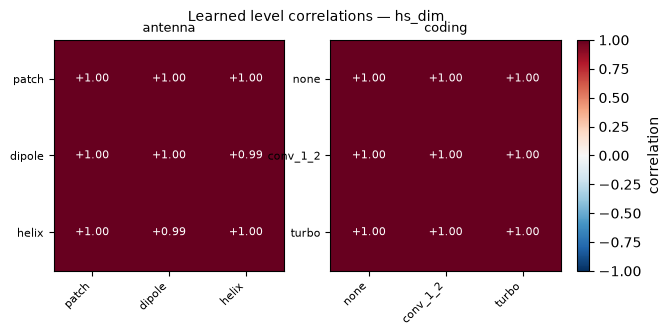

In [11]:
from mvlse import report

report.level_correlation_heatmap(result);

For an **ordinal** variable a good fit comes out monotone — neighbouring levels more
correlated than distant ones — without having been told there is an order. For a
**nominal** one any pattern is admissible, negative entries included.

## 7. Plots

`boundary_panels` needs exactly two continuous variables (it draws a contour). The other
plots work at any dimension.

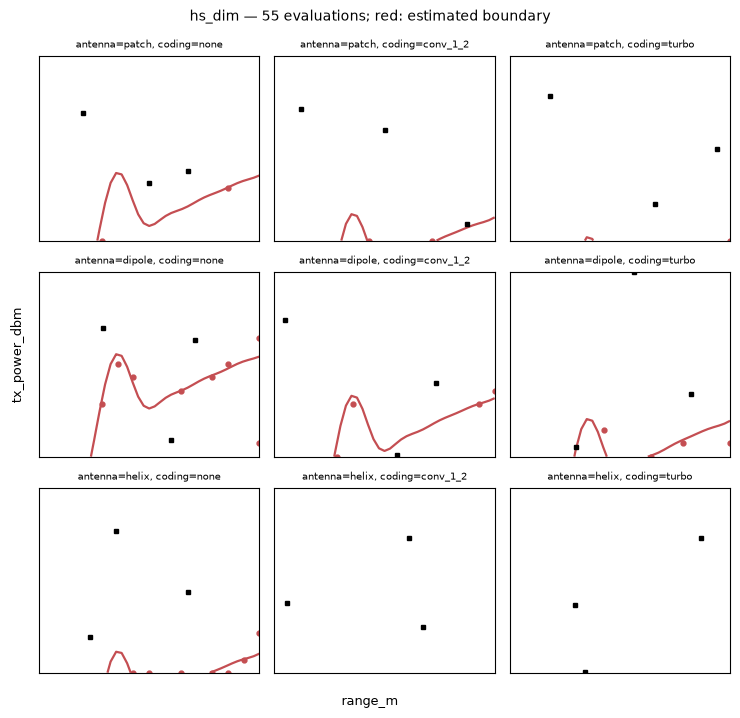

In [12]:
report.boundary_panels(result);

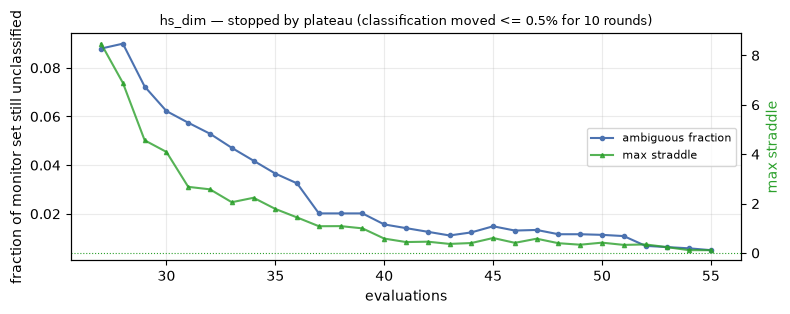

In [13]:
report.convergence(result);

In [14]:
# a GIF of the boundary tightening; requires keep_snapshots=True
report.animate_boundary(result, path="link_margin.gif", max_frames=24)

PosixPath('link_margin.gif')

---

# Variants

## A. A noisy blackbox

Return `(value, standard_error)` instead of a bare number and the standard errors go on
the covariance diagonal as fixed known noise. Nothing else changes — it is detected from
what you return.

Predictions are then of the **latent, noise-free** response, which is what a level set is.

In [15]:
rng = np.random.default_rng(0)


def noisy_link_margin(points):
    clean = link_margin(points)
    out = []
    for p, value in zip(points, clean):
        se = 0.3 + 1.2 * (p["range_m"] / 5000.0)     # noisier at long range
        out.append((value + se * rng.standard_normal(), se))
    return out


noisy_result = run_lse(space, noisy_link_margin, threshold=0.0,
                       n_init_per_category=3, max_evaluations=120, seed=7, verbose=False)

print(noisy_result.summary())
print("standard errors seen by the GP:", noisy_result.se.min().round(2), "to", noisy_result.se.max().round(2))

level set: <= 0   method: hs_dim (squar_exp)
evaluations: 58 (27 initial + 31 acquired) in 32 rounds, 16.4s
stopped by: plateau (classification moved <= 0.5% for 10 rounds)
final: max straddle=+1.3934  ambiguous=5.4%
standard errors seen by the GP: 0.38 to 1.5


Any of these return shapes work:

```python
[1.2, 0.7, ...]                    # deterministic
[(1.2, 0.1), (0.7, 0.3), ...]      # (value, standard error)
[Observation(1.2, 0.1), ...]       # the same, named
np.array([[1.2, 0.1], ...])        # (n, 2) array
[{"y": 1.2, "se": 0.1}, ...]       # mappings; "se" optional
```

## B. Cache evaluations so a rerun is free

Point `store` at a file. Every evaluation is appended as JSON; a rerun calls the blackbox
only for points it has never seen. Use this whenever a call costs more than a second.

In [16]:
cached = run_lse(space, link_margin, threshold=0.0,
                 n_init_per_category=2, max_evaluations=60,
                 store="link_margin_cache.jsonl", seed=7, verbose=False)

# rerunning with a bigger budget re-uses everything above and pays only for the new points
extended = run_lse(space, link_margin, threshold=0.0,
                   n_init_per_category=2, max_evaluations=90,
                   store="link_margin_cache.jsonl", seed=7, verbose=False)

print(f"{cached.n_evaluations} then {extended.n_evaluations} evaluations, sharing one cache file")

56 then 56 evaluations, sharing one cache file


## C. Choose a different kernel or correlation function

`method` picks how the **discrete** variables enter — the five methods of `GP2.pdf`:

| `method` | paper | idea |
|---|---|---|
| `category_wise` | §3.2 | one independent GP per category; the reference |
| `dc` | Eq. 15 | each level becomes a number, treated as continuous |
| `gower` | Eq. 18 | a 0/1 mismatch score as the discrete distance |
| `hs_full` | Eq. 19 | one free correlation per pair of categories |
| `hs_dim` | Eq. 23 | one small matrix per discrete variable — **the default** |

`correlation` picks the **continuous** part (Eq. 8): `squar_exp` (default), `abs_exp`,
`pow_exp`, `matern32`, `matern52`. The two compose, so `gower` + `matern52` is available.

In [17]:
for method in ["category_wise", "dc", "gower", "hs_dim"]:
    r = run_lse(space, link_margin, threshold=0.0, method=method,
                n_init_per_category=3, max_evaluations=90, seed=7, verbose=False)
    print(f"{method:14s} n={r.n_evaluations:4d}  stopped by {r.stop_reason}")

category_wise  n=  63  stopped by plateau (classification moved <= 0.5% for 10 rounds)
dc             n=  54  stopped by plateau (classification moved <= 0.5% for 10 rounds)
gower          n=  67  stopped by plateau (classification moved <= 0.5% for 10 rounds)
hs_dim         n=  55  stopped by plateau (classification moved <= 0.5% for 10 rounds)


In [18]:
for correlation in ["squar_exp", "matern32", "matern52"]:
    r = run_lse(space, link_margin, threshold=0.0, correlation=correlation,
                n_init_per_category=3, max_evaluations=90, seed=7, verbose=False)
    print(f"{correlation:10s} n={r.n_evaluations:4d}  stopped by {r.stop_reason}")

squar_exp  n=  55  stopped by plateau (classification moved <= 0.5% for 10 rounds)
matern32   n=  37  stopped by plateau (classification moved <= 0.5% for 10 rounds)
matern52   n=  37  stopped by plateau (classification moved <= 0.5% for 10 rounds)


## D. A one-point-at-a-time blackbox

Wrap it. `pointwise` loops; `parallel` fans out over joblib (the function must be
picklable, so no lambdas).

In [19]:
from mvlse import pointwise


def one_point(p):
    return link_margin([p])[0]

r = run_lse(space, pointwise(one_point), threshold=0.0,
            n_init_per_category=2, max_evaluations=40, seed=7, verbose=False)
print(r.summary().splitlines()[1])

evaluations: 40 (18 initial + 22 acquired) in 23 rounds, 4.7s


```python
from mvlse import parallel

blackbox = parallel(one_point, n_jobs=-1)
```

If your simulator already parallelises internally, pass it directly as a batch blackbox
instead — nesting two worker pools does not end well.

## E. Full control over the configuration

Every knob lives on `LseConfig`, and a run is fully described by it plus the seed.

In [20]:
config = LseConfig(
    threshold=0.0,
    method="hs_dim",
    correlation="squar_exp",
    greater_is_inside=False,   # True for f >= threshold

    n_init_per_category=3,
    max_evaluations=150,
    batch_size=4,              # points per round, for a slow blackbox
    min_batch_distance=0.15,   # keep a batch from clustering on one spot

    kappa=1.96,                # straddle width; 1.96 = a 95% interval
    flip_window=10,            # plateau stopping: rounds to look back over
    flip_tolerance=0.005,      # ... and how much movement is "stopped"

    seed=7,
    n_starts=6,                # optimiser restarts on the first fit
    keep_snapshots=False,
    verbose=False,
)

result = run_lse(space, link_margin, config=config)
print(result.summary())

level set: <= 0   method: hs_dim (squar_exp)
evaluations: 67 (27 initial + 40 acquired) in 11 rounds, 4.6s
stopped by: confident (max straddle < 0)
final: max straddle=-0.0603  ambiguous=0.4%


## F. Supply your own candidate or initial designs

By default the loop builds a lattice for `q <= 2` continuous variables and a scrambled
Sobol' cloud beyond. Override either when you have a reason — a region you must cover,
points you have already measured.

In [21]:
from mvlse import random_candidates

candidates = random_candidates(space, n_per_category=400, seed=1)
initial = stratified_doe(space, n_per_category=3, seed=99)

result = run_lse(space, link_margin, threshold=0.0,
                 candidates=candidates, initial_design=initial,
                 max_evaluations=100, seed=7, verbose=False)
print(result.summary())

level set: <= 0   method: hs_dim (squar_exp)
evaluations: 53 (27 initial + 26 acquired) in 27 rounds, 8.9s
stopped by: plateau (classification moved <= 0.5% for 10 rounds)
final: max straddle=+0.3083  ambiguous=0.8%


---

## Where to go next

- `docs/FORMULA_SHEET.md` — every equation of `GP2.pdf` beside the line that implements it
- `docs/CHOOSING.md` — which `method` to use, and when the choice matters
- `mvlse.problems` — the benchmark surfaces, if you want to check a method against a
  known answer before trusting it on yours